In [1]:
!pip install qiskit==2.5.2 qiskit-aer==0.17.2 qiskit-algorithms==0.4.0 pylatexenc

In [2]:
# Importing standard Qiskit libraries
from qiskit import QuantumCircuit, transpile

In [3]:
# Importing standard Qiskit libraries
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import Parameter
from qiskit_aer.primitives import EstimatorV2
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP

In [4]:
paulis = ['Z']
weights = [1]
pauli_op = [([pauli,weight]) for pauli,weight in zip(paulis,weights)]
hamiltonian1 = SparsePauliOp.from_list([ op for op in pauli_op ])
print(hamiltonian1)

SparsePauliOp(['Z'],
              coeffs=[1.+0.j])


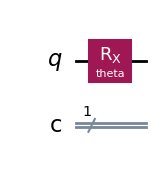

In [5]:
theta = Parameter('theta')
ansatz_1 = QuantumCircuit(1, 1)
ansatz_1.rx(theta, 0)
ansatz_1.draw(output='mpl')

In [6]:
vqe_solver=VQE(estimator=EstimatorV2(),
               ansatz=ansatz_1, optimizer=SLSQP(maxiter=100))
result_vqe = vqe_solver.compute_minimum_eigenvalue(operator=hamiltonian1)
vqe_res1 = result_vqe.optimal_value
print('VQE Result of H=Z : ', vqe_res1)

VQE Result of H=Z :  -0.9999999999757035


In [7]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import Parameter
from qiskit_aer.primitives import EstimatorV2
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP

In [8]:
paulis = ['Z','X','I']
weights = [3,2,2]
pauli_op = [([pauli,weight]) for pauli,weight in zip(paulis,weights)]
hamiltonian2 = SparsePauliOp.from_list([ op for op in pauli_op ])
print(hamiltonian2)

SparsePauliOp(['Z', 'X', 'I'],
              coeffs=[3.+0.j, 2.+0.j, 2.+0.j])


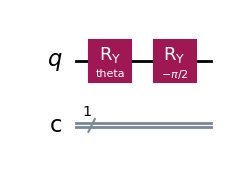

In [9]:
theta = Parameter('theta')
ansatz_2 = QuantumCircuit(1, 1)
ansatz_2.ry(theta, 0)
ansatz_2.ry(-np.pi/2, 0)
ansatz_2.draw(output='mpl')

In [10]:
vqe_solver=VQE(estimator=EstimatorV2(),
               ansatz=ansatz_2, optimizer=SLSQP(maxiter=100))
result_vqe = vqe_solver.compute_minimum_eigenvalue(operator=hamiltonian2)
vqe_res1 = result_vqe.optimal_value
print('VQE Result of H=3Z + 2X + 2I: ', vqe_res1)

VQE Result of H=3Z + 2X + 2I:  -1.605551236323689


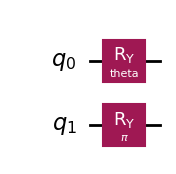

In [11]:
theta = Parameter('theta')
ansatz_3 = QuantumCircuit(2)
ansatz_3.ry(theta, 0)
ansatz_3.ry(np.pi, 1)
display(ansatz_3.draw('mpl'))

In [12]:
from qiskit.quantum_info import SparsePauliOp

# Define H = ZZ (1.0 * ZZ)
paulis = ['ZZ']
weights = [1.0]

hamiltonian_zz = SparsePauliOp(paulis, coeffs=weights)
print(hamiltonian_zz)

SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j])


In [13]:
estimator = EstimatorV2()
vqe_solver = VQE(estimator=estimator, ansatz=ansatz_3, optimizer=SLSQP(maxiter=100))
result_vqe = vqe_solver.compute_minimum_eigenvalue(operator=hamiltonian_zz)
vqe_res1 = result_vqe.optimal_value
print('VQE Result of H=ZZ: ', vqe_res1)

VQE Result of H=ZZ:  -0.999999999998679


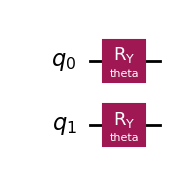

In [14]:
theta = Parameter('theta')
ansatz_4 = QuantumCircuit(2)
ansatz_4.ry(theta, 0)
ansatz_4.ry(theta, 1)
display(ansatz_4.draw('mpl'))

In [15]:
estimator = EstimatorV2()
vqe_solver = VQE(estimator=estimator, ansatz=ansatz_4, optimizer=SLSQP(maxiter=100))
result_vqe = vqe_solver.compute_minimum_eigenvalue(operator=hamiltonian_zz)
vqe_res1 = result_vqe.optimal_value
print('VQE Result of H=ZZ: ', vqe_res1)

VQE Result of H=ZZ:  4.577060952470902e-12


In [16]:
import importlib.metadata as _md
import os, platform
from IPython.display import HTML, display

_pkgs = ['qiskit', 'qiskit-aer', 'qiskit-algorithms']
_html = '<h3>Version Information</h3><table>'
_html += '<tr>' + ''.join(f'<th>{h}</th>' for h in ['Software','Version']) + '</tr>'
for _p in _pkgs:
    try:
        _html += f'<tr><td><code>{_p}</code></td><td>{_md.version(_p)}</td></tr>'
    except _md.PackageNotFoundError:
        pass
_html += "<tr><th colspan='2'>System information</th></tr>"
_html += f"<tr><td>Python version</td><td>{platform.python_version()}</td></tr>"
_html += f"<tr><td>Python implementation</td><td>{platform.python_implementation()}</td></tr>"
_html += f"<tr><td>OS</td><td>{platform.system()}</td></tr>"
_html += f"<tr><td>CPUs</td><td>{os.cpu_count()}</td></tr>"
_html += f"<tr><td>Memory (Gb)</td><td>{round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / 1024 ** 3, 4)}</td></tr>"
_html += f"<tr><td colspan='2'>{platform.node()}</td></tr></table>"

display(HTML(_html))